In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Collection
First of all we have to collect the data to be processed, analyzed and to train a model. Here, we have downloaded the data from (Kaggle). After downloading the data, first we have to import it in notebook using pandas library. Then, we dispalyed first 10 rows contained in the downloaed data and observe some basic information about the data for further processing.

In [354]:
df = pd.read_csv('bike_buyers.csv')
df.head(10)                 

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
5,13507,Married,Female,10000.0,2.0,Partial College,Manual,Yes,0.0,1-2 Miles,Europe,50.0,No
6,27974,Single,Male,160000.0,2.0,High School,Management,NaN,4.0,0-1 Miles,Pacific,33.0,Yes
7,19364,Married,Male,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,43.0,Yes
8,22155,NaN,Male,20000.0,2.0,Partial High School,Clerical,Yes,2.0,5-10 Miles,Pacific,58.0,No
9,19280,Married,Male,NaN,2.0,Partial College,Manual,Yes,1.0,0-1 Miles,Europe,NaN,Yes


In [355]:
df.shape

(1000, 13)

In [356]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital Status    993 non-null    object 
 2   Gender            989 non-null    object 
 3   Income            994 non-null    float64
 4   Children          992 non-null    float64
 5   Education         1000 non-null   object 
 6   Occupation        1000 non-null   object 
 7   Home Owner        996 non-null    object 
 8   Cars              991 non-null    float64
 9   Commute Distance  1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Age               992 non-null    float64
 12  Purchased Bike    1000 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 101.7+ KB


In [357]:
df.describe()

,ID,Income,Children,Cars,Age
count,1000.000000,994.000000,992.000000,991.000000,992.000000
mean,19965.992000,56267.605634,1.910282,1.455096,44.181452
std,5347.333948,31067.817462,1.626910,1.121755,11.362007
min,11000.000000,10000.000000,0.000000,0.000000,25.000000
25%,15290.750000,30000.000000,0.000000,1.000000,35.000000
50%,19744.000000,60000.000000,2.000000,1.000000,43.000000
75%,24470.750000,70000.000000,3.000000,2.000000,52.000000
max,29447.000000,170000.000000,5.000000,4.000000,89.000000


# 2. Data Cleaning & Transformation
After importing the data and observing the basic inormation about the data, the second step we perform is data cleaning and some transformations. First, we handled some null data and some outliers. Second we fixed the data type and perform feature engineering.

## 2.1 Handle Missing Values
Here the count of null values are very less compared to the total data. Maximum number of null value contained is 11 which is about 1.1%. So, the null values conatined were droped.

In [358]:
df.isnull().sum()

ID                   0
Marital Status       7
Gender              11
Income               6
Children             8
Education            0
Occupation           0
Home Owner           4
Cars                 9
Commute Distance     0
Region               0
Age                  8
Purchased Bike       0
dtype: int64

In [359]:
df.dropna(inplace=True)

## 2.2 Handel Mistake/ Outlier Values
Here, we have checked some column whcih might have incorrect entries. For example age values and income,
if there is some negative data and unrealistic income. 

In case of outliers, we have plot boxplot to observe the outliers. Income and Age data contain only 8 and 4 outliers so it is removed while cars have 51 outliers which is filled with median because the median is not affected by extreme values. This helps reduce the impact of outliers on analysis while keeping the dataset size unchanged. 

In [360]:
mistake_age_count = df[df['Age'] < 0].shape[0]
mistake_age_count

0

In [361]:
mistake_age = df[df['Age'] > 123].shape[0]
mistake_age

0

In [362]:
mistake_income_count = df[df['Income'] > 500000].shape[0]
mistake_income_count

0

{'whiskers': [<matplotlib.lines.Line2D at 0x1afbf174ef0>,
 'caps': [<matplotlib.lines.Line2D at 0x1afbf175400>,
 'boxes': [<matplotlib.lines.Line2D at 0x1afbf174d40>],
 'medians': [<matplotlib.lines.Line2D at 0x1afbf1759d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1afbf175c70>],
 'means': []}

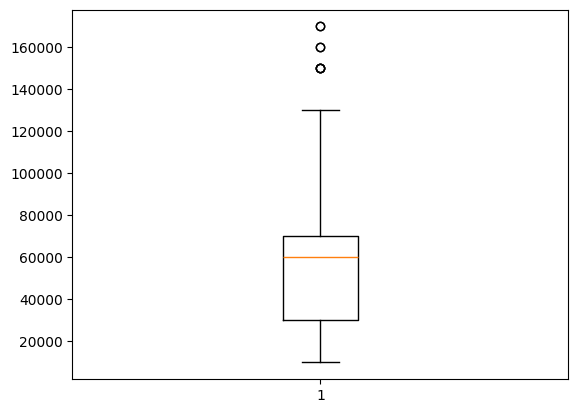

In [363]:
plt.boxplot(df['Income'])

In [364]:
q1=df['Income'].quantile(0.25)
q3=df['Income'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr
len(df[(df['Income']<lower) | (df['Income']>upper)])

8

In [365]:
indexes_to_drop=df[(df['Income']<lower) | (df['Income']>upper)].index
df.drop(indexes_to_drop, inplace=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x1afbf1b7c80>,
 'caps': [<matplotlib.lines.Line2D at 0x1afbf1e02f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1afbf1b7950>],
 'medians': [<matplotlib.lines.Line2D at 0x1afbf1e07d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1afbf1e0ad0>],
 'means': []}

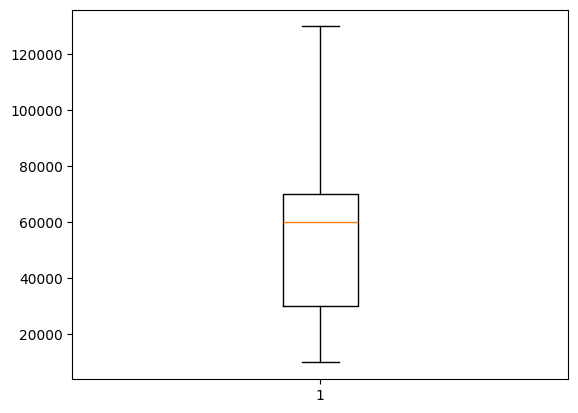

In [366]:
plt.boxplot(df['Income'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1afbf21aab0>,
 'caps': [<matplotlib.lines.Line2D at 0x1afbf21b0b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1afbf21a7b0>],
 'medians': [<matplotlib.lines.Line2D at 0x1afbf21b6b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1afbf21b9e0>],
 'means': []}

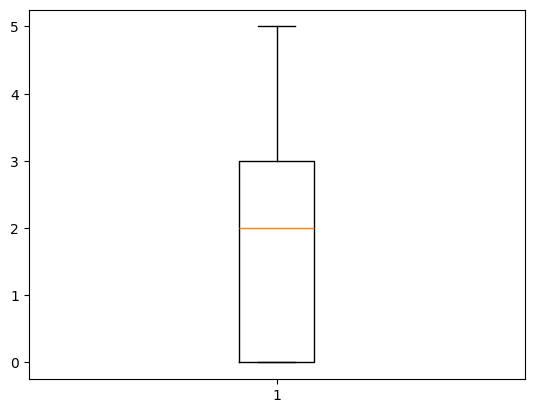

In [367]:
plt.boxplot(df['Children'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1afc7b610d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1afc7b616d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1afc7b60e60>],
 'medians': [<matplotlib.lines.Line2D at 0x1afc7b61ca0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1afc7b61f70>],
 'means': []}

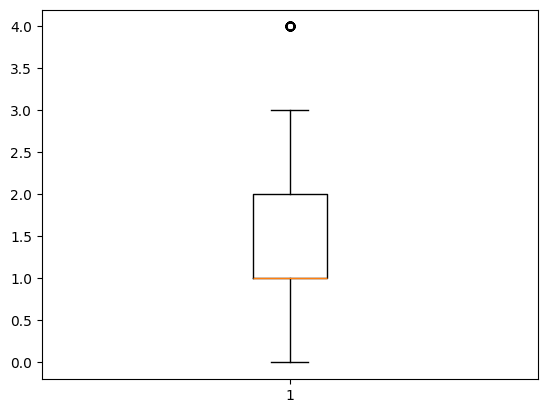

In [368]:
plt.boxplot(df['Cars'])

In [369]:
q1=df['Cars'].quantile(0.25)
q3=df['Cars'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr
len(df[(df['Cars']<lower) | (df['Cars']>upper)])

51

In [370]:
median_cars = df['Cars'].median()
df.loc[(df['Cars'] < lower) | (df['Cars'] > upper), 'Cars'] = median_cars

{'whiskers': [<matplotlib.lines.Line2D at 0x1afc7d2b8c0>,
 'caps': [<matplotlib.lines.Line2D at 0x1afc7d29eb0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1afc7d28bc0>],
 'medians': [<matplotlib.lines.Line2D at 0x1afc7d28da0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1afc7d28470>],
 'means': []}

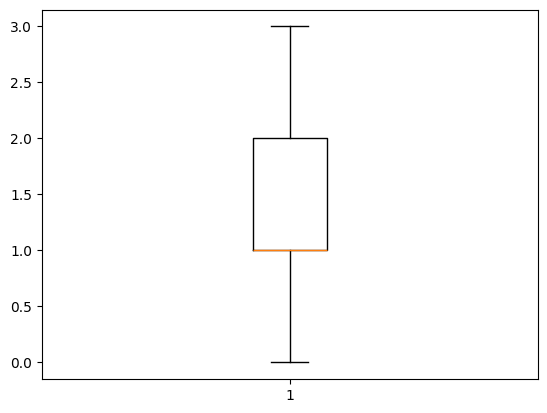

In [371]:
plt.boxplot(df['Cars'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1afbc3ceab0>,
 'caps': [<matplotlib.lines.Line2D at 0x1afbc3cf320>,
 'boxes': [<matplotlib.lines.Line2D at 0x1afc7d0bdd0>],
 'medians': [<matplotlib.lines.Line2D at 0x1afbc3ce360>],
 'fliers': [<matplotlib.lines.Line2D at 0x1afbc3ccb90>],
 'means': []}

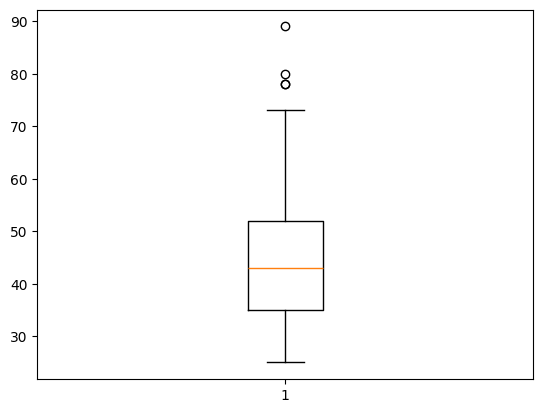

In [372]:
plt.boxplot(df['Age'])

In [373]:
q1=df['Age'].quantile(0.25)
q3=df['Age'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr
len(df[(df['Age']<lower) | (df['Age']>upper)])

4

In [374]:
indexes_to_drop=df[(df['Age']<lower) | (df['Age']>upper)].index
df.drop(indexes_to_drop, inplace=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x1afbc1546e0>,
 'caps': [<matplotlib.lines.Line2D at 0x1afbc155af0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1afbc24c590>],
 'medians': [<matplotlib.lines.Line2D at 0x1afbc154c80>],
 'fliers': [<matplotlib.lines.Line2D at 0x1afbc155bb0>],
 'means': []}

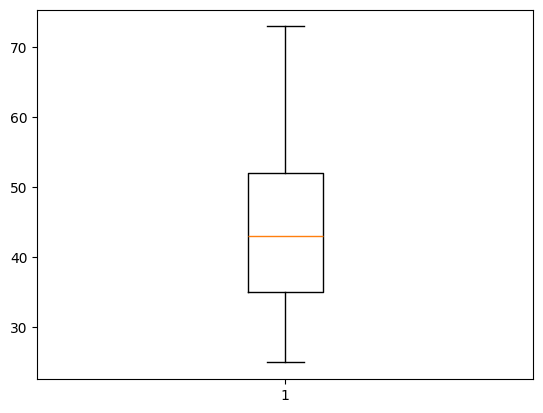

In [375]:
plt.boxplot(df['Age'])

## 2.3 Data Type Fixing
Here, I have converted numeric data type to int32 and Categorical type to category which uses less memory and is efficient for further analysis.

In [376]:
df.dtypes

ID                    int64
Marital Status       object
Gender               object
Income              float64
Children            float64
Education            object
Occupation           object
Home Owner           object
Cars                float64
Commute Distance     object
Region               object
Age                 float64
Purchased Bike       object
dtype: object

In [377]:
int_cols = ['Children', 'Cars', 'Age']

In [378]:
for col in int_cols:
    df[col] = df[col].astype('int32')

In [379]:
categorical_cols = ["Marital Status", "Gender", "Education", "Occupation", "Home Owner", "Commute Distance", "Region", "Purchased Bike"]
for col in categorical_cols:
    df[col] = df[col].astype("category")

In [380]:
df.dtypes

ID                     int64
Marital Status      category
Gender              category
Income               float64
Children               int32
Education           category
Occupation          category
Home Owner          category
Cars                   int32
Commute Distance    category
Region              category
Age                    int32
Purchased Bike      category
dtype: object

## 2.4 Feature Engineering
Here three different new columns were created using eisting three column. Age is categorized based upon different age range, income also categorized based upon different income range given in the data and lastly based upon commute distance Commute category was created.

In [381]:
df['Age'].value_counts().to_frame().reset_index()

,Age,count
0,40,37
1,47,35
2,36,35
3,38,34
4,35,34
5,43,34
6,42,33
7,32,33
8,34,30
9,37,30


In [382]:
conditions = [
    (df['Age'] >=0) & (df['Age'] <= 12),
    (df['Age'] >=13) & (df['Age'] <= 24),
    (df['Age'] >=25) & (df['Age'] <= 64),
    (df['Age'] >= 65) & (df['Age'] <=100)
]
mappings = ['Child', 'Young Adult', 'Adult', 'Senior']

In [383]:
df['Age Group'] = np.select(conditions, mappings, default = 'Unknown')

In [384]:
df['Income'].value_counts().to_frame().reset_index()

,Income,count
0,60000.0,155
1,40000.0,145
2,30000.0,133
3,70000.0,119
4,80000.0,84
5,10000.0,72
6,20000.0,68
7,50000.0,38
8,90000.0,37
9,130000.0,31


In [385]:
conditions = [
    (df['Income'] >=0) & (df['Income'] <= 20000),
    (df['Income'] >=20001) & (df['Income'] <= 40000),
    (df['Income'] >=40001) & (df['Income'] <= 70000),
    (df['Income'] >=70001) & (df['Income'] <= 100000),
    (df['Income'] > 100001)
]
mappings = ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']

In [386]:
df['Income Range'] = np.select(conditions, mappings, default= 'Unknown')

In [387]:
df['Commute Distance'].value_counts().to_frame().reset_index()

,Commute Distance,count
0,0-1 Miles,331
1,5-10 Miles,181
2,1-2 Miles,163
3,2-5 Miles,158
4,10+ Miles,107


In [388]:
conditions=[df['Commute Distance']=='0-1 Miles', 
            df['Commute Distance']=='1-2 Miles',
            df['Commute Distance']=='2-5 Miles',
            df['Commute Distance']=='5-10 Miles',
            df['Commute Distance']=='10+ Miles']
mappings=['Very Near','Near','Moderate Distance','Far','Very Far']

In [389]:
df['Commute Category']=np.select(conditions,mappings,default='Unknown')

In [390]:
df.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike,Age Group,Income Range,Commute Category
0,12496,Married,Female,40000.0,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,No,Adult,Lower-Middle,Very Near
1,24107,Married,Male,30000.0,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,No,Adult,Lower-Middle,Very Near
2,14177,Married,Male,80000.0,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,No,Adult,Upper-Middle,Moderate Distance
4,25597,Single,Male,30000.0,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Yes,Adult,Lower-Middle,Very Near
5,13507,Married,Female,10000.0,2,Partial College,Manual,Yes,0,1-2 Miles,Europe,50,No,Adult,Low,Near


# 3. Exploratory Data Analysis

## 3.1 Univariate Analysis

In [391]:
import seaborn as sns

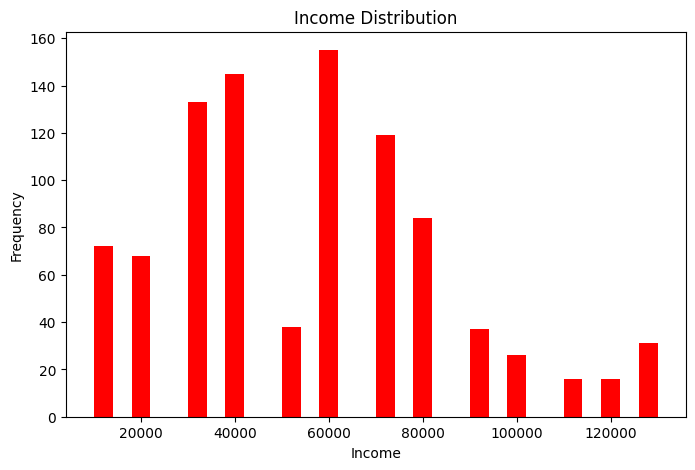

In [392]:
plt.figure(figsize=(8,5))
plt.hist(df['Income'], bins=30, color='red')  
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

From above bargraph, it is clear that people with income of 60000 were more than 150 in numbers whereas about 15 people have income of 120000. While others have income starting from about 10000 to approximately 130000. 

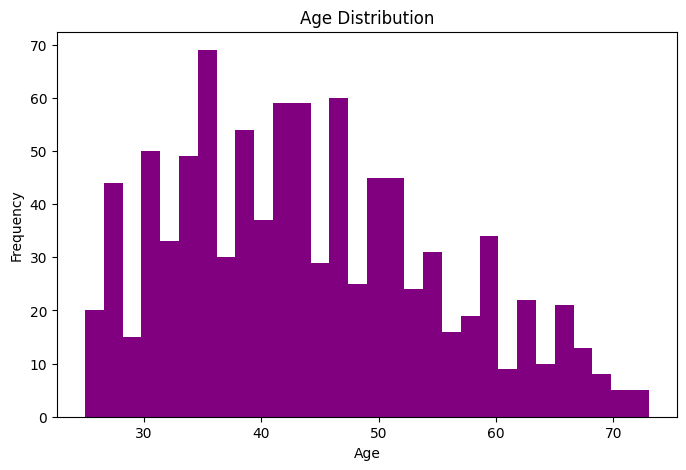

In [393]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=30, color='purple')   
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

From above graph of Age distribution, people with age of about 35 years were highest in numbers. People with age of 70 and above are least in numbers. Overall, the minimum age of people starts with almost 25 yeras and ends with people of age about 75 years. 

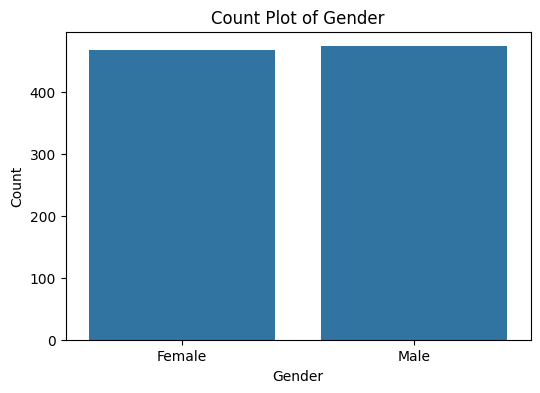

In [394]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Count Plot of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Overall, both gender have almost similar number though Male are slight high in numbers as compared to female.

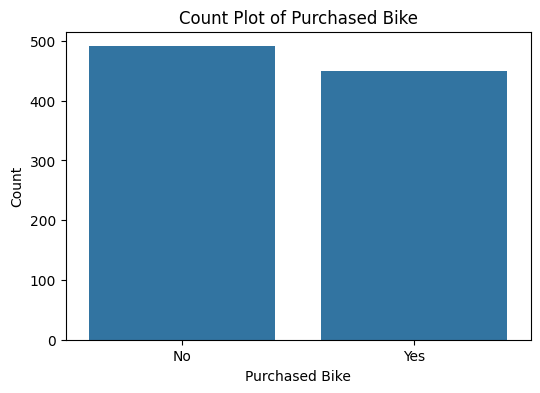

In [395]:
plt.figure(figsize=(6,4))
sns.countplot(x='Purchased Bike', data=df)
plt.title("Count Plot of Purchased Bike")
plt.xlabel("Purchased Bike")
plt.ylabel("Count")
plt.show()

Number of people not having bike is slight high which is almost 500 and people who purchased bike are of about 450.

# 3.2 Bivariant Analysis

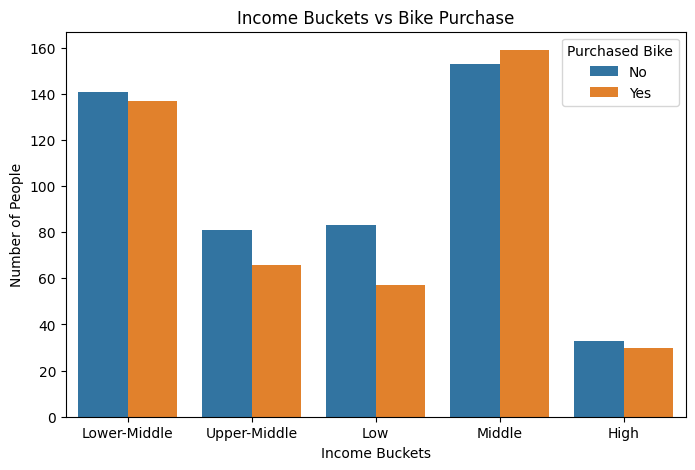

In [396]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['Income Range'],hue=df['Purchased Bike'], data=df)
plt.title("Income Buckets vs Bike Purchase")
plt.xlabel("Income Buckets")
plt.ylabel("Number of People")
plt.show()

The graph shows that medium-income individuals tend to buy bikes more often, but this income group also has the highest number of people who did not choose to buy a bike.

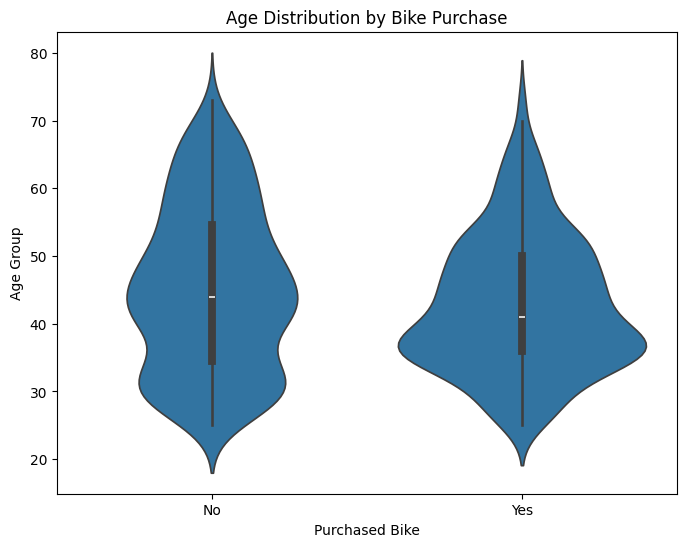

In [397]:
plt.figure(figsize=(8,6))
sns.violinplot(x='Purchased Bike', y='Age', data=df)
plt.title("Age Distribution by Bike Purchase")
plt.xlabel("Purchased Bike")
plt.ylabel("Age Group")
plt.show()

The violin plot shows that bike buyers are generally younger, with a median age around 39, while non-buyers are slightly older, with a median age around 44. Both groups cover a similar age range, but bike buyers are more concentrated between 35–40 years, whereas non-buyers are more common around 45-50 years. Overall, younger individuals are slightly more likely to purchase a bike.

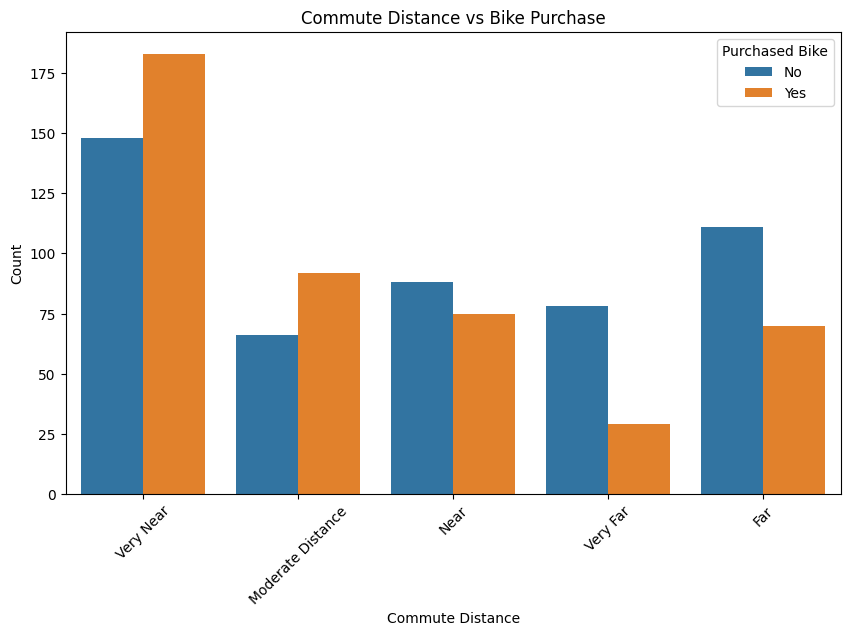

In [398]:
plt.figure(figsize=(10,6))
sns.countplot(x='Commute Category', hue='Purchased Bike', data=df)
plt.title("Commute Distance vs Bike Purchase")
plt.xlabel("Commute Distance")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Above graph shows that, people who have less commute distance whcih is 0-1 Miles have purchased highest number bikes and the number for not having bike is also highest for this category. People who have to travel 10+ Miles distance purchased least number of bikes.  

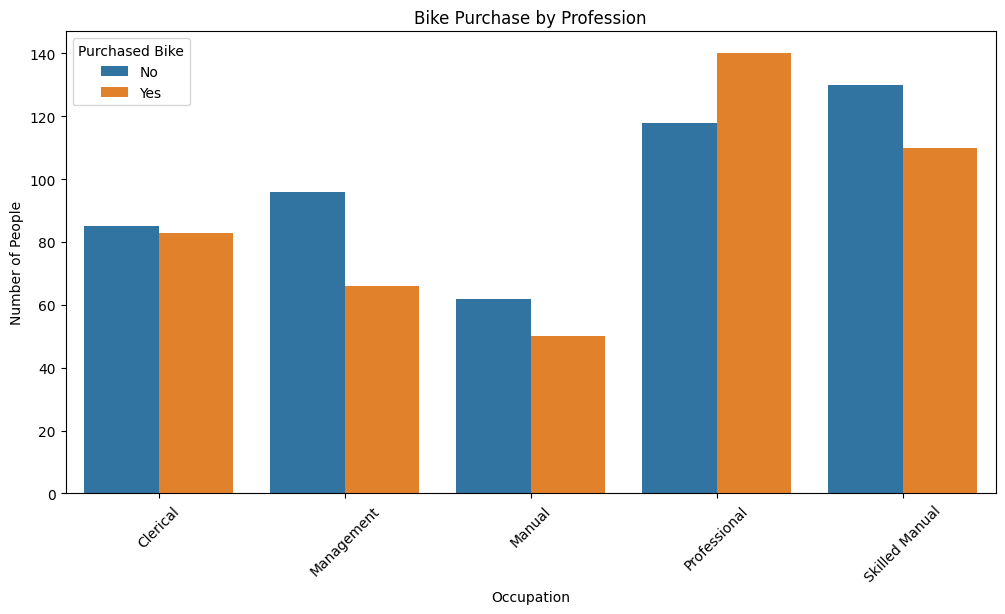

In [399]:
plt.figure(figsize=(12,6))
sns.countplot(x='Occupation', hue='Purchased Bike', data=df)
plt.title("Bike Purchase by Profession")
plt.xlabel("Occupation")
plt.ylabel("Number of People")
plt.xticks(rotation=45)
plt.show()

From the above chart we can conclude that, number of people who are involved in Professional work have bikes and those who were doing manual works do not purchased bikes.

## 3.3 Insight summary
1. Most people earn between 30,000 and 80,000, and medium-income individuals both buy bikes the most and account for a large number of non-buyers, indicating mixed purchasing behavior in this group.
2. Bike purchasers tend to be slightly younger, with the median age lower than non-purchasers, and most customers fall in the 30–50 age range.
3. The gender split is nearly balanced, with males slightly outnumbering females, suggesting gender has minimal impact on purchase behavior.
4. Overall, more individuals do not own a bike than those who do, but purchasers have a slightly higher median income and a more concentrated income distribution.
5. Customers living near the store are the most frequent buyers, highlighting that distance or convenience strongly influences bike purchase decisions.

# 4. Machine Learning Modeling
Here I have used 3 different models:
1. Logistic Regression
2. K-Nearest Neighbors(KNN)
3. Random Forest Classifier()

In [400]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 940 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   ID                940 non-null    int64   
 1   Marital Status    940 non-null    category
 2   Gender            940 non-null    category
 3   Income            940 non-null    float64 
 4   Children          940 non-null    int32   
 5   Education         940 non-null    category
 6   Occupation        940 non-null    category
 7   Home Owner        940 non-null    category
 8   Cars              940 non-null    int32   
 9   Commute Distance  940 non-null    category
 10  Region            940 non-null    category
 11  Age               940 non-null    int32   
 12  Purchased Bike    940 non-null    category
 13  Age Group         940 non-null    object  
 14  Income Range      940 non-null    object  
 15  Commute Category  940 non-null    object  
dtypes: category(8), float64(1), int

## 4.1 Data Preparation

In [401]:
#Dropping unneccesary columns
df.drop(['ID', 'Commute Distance', 'Age Group', 'Income Range' ], axis=1, inplace=True)

In [402]:
X=df.drop(columns=['Purchased Bike'])
y=df['Purchased Bike']

In [403]:
X

,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Region,Age,Commute Category
0,Married,Female,40000.0,1,Bachelors,Skilled Manual,Yes,0,Europe,42,Very Near
1,Married,Male,30000.0,3,Partial College,Clerical,Yes,1,Europe,43,Very Near
2,Married,Male,80000.0,5,Partial College,Professional,No,2,Europe,60,Moderate Distance
4,Single,Male,30000.0,0,Bachelors,Clerical,No,0,Europe,36,Very Near
5,Married,Female,10000.0,2,Partial College,Manual,Yes,0,Europe,50,Near
...,...,...,...,...,...,...,...,...,...,...,...
994,Married,Male,80000.0,5,Partial College,Professional,Yes,3,North America,46,Near
995,Married,Male,60000.0,2,High School,Professional,Yes,2,North America,54,Moderate Distance
996,Single,Male,70000.0,4,Graduate Degree,Professional,Yes,0,North America,35,Moderate Distance
998,Single,Male,100000.0,3,Bachelors,Management,No,3,North America,38,Near


In [404]:
y

0       No
1       No
2       No
4      Yes
5       No
      ... 
994     No
995    Yes
996    Yes
998     No
999    Yes
Name: Purchased Bike, Length: 940, dtype: category
Categories (2, object): ['No', 'Yes']

In [405]:
#Label encoding the target column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [406]:
y_encoded

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,

In [407]:
#One hot encoding the features
numeric_cols = ['Income','Children','Cars','Age']
categorical_cols = ['Marital Status','Gender','Education','Occupation','Region','Home Owner','Commute Category']
X_encoded = pd.get_dummies(X[categorical_cols], drop_first=True)
bool_cols = X_encoded.select_dtypes('bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

In [408]:
X_final = pd.concat([X[numeric_cols], X_encoded], axis=1)

In [409]:
X_final

,Income,Children,Cars,Age,Marital Status_Single,Gender_Male,Education_Graduate Degree,Education_High School,Education_Partial College,Education_Partial High School,...,Occupation_Manual,Occupation_Professional,Occupation_Skilled Manual,Region_North America,Region_Pacific,Home Owner_Yes,Commute Category_Moderate Distance,Commute Category_Near,Commute Category_Very Far,Commute Category_Very Near
0,40000.0,1,0,42,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
1,30000.0,3,1,43,0,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
2,80000.0,5,2,60,0,1,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
4,30000.0,0,0,36,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,10000.0,2,0,50,0,0,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,80000.0,5,3,46,0,1,0,0,1,0,...,0,1,0,1,0,1,0,1,0,0
995,60000.0,2,2,54,0,1,0,1,0,0,...,0,1,0,1,0,1,1,0,0,0
996,70000.0,4,0,35,1,1,1,0,0,0,...,0,1,0,1,0,1,1,0,0,0
998,100000.0,3,3,38,1,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0


In [410]:
X_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 940 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Income                              940 non-null    float64
 1   Children                            940 non-null    int32  
 2   Cars                                940 non-null    int32  
 3   Age                                 940 non-null    int32  
 4   Marital Status_Single               940 non-null    int64  
 5   Gender_Male                         940 non-null    int64  
 6   Education_Graduate Degree           940 non-null    int64  
 7   Education_High School               940 non-null    int64  
 8   Education_Partial College           940 non-null    int64  
 9   Education_Partial High School       940 non-null    int64  
 10  Occupation_Management               940 non-null    int64  
 11  Occupation_Manual                   940 non-null  

In [411]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

Spliting the dataset into train and test.

In [412]:
X_train, X_test, y_train, y_test = train_test_split(X_final,y_encoded,test_size=0.2, random_state=42)

Applying feature scaling (StandardScaler)

In [413]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [414]:
model1=LogisticRegression()
model2=KNeighborsClassifier()
model3=RandomForestClassifier()

# 4.2 Model Training

In [415]:
model1.fit(X_train,y_train)
model2.fit(X_train,y_train)
model3.fit(X_train,y_train)

C:\Users\Dell\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 4.3 Model Evaluation

In [416]:
y1=model1.predict(X_test)
y2=model2.predict(X_test)
y3=model3.predict(X_test)

Calculating the accuracy of each model.

In [417]:
accuracy1=accuracy_score(y_test,y1)
accuracy2=accuracy_score(y_test,y2)
accuracy3=accuracy_score(y_test,y3)

In [418]:
accuracy1

0.6436170212765957

In [419]:
accuracy2

0.6968085106382979

In [420]:
accuracy3

0.7127659574468085

Random Forest achieved the highest accuracy of 72.34% compared to Logistic Regression and KNN.

comparison table showing all metrics.

In [421]:
confusion_matrix1=confusion_matrix(y_test,y1)
confusion_matrix1

array([[64, 25],
       [42, 57]])

In [422]:
precision1=precision_score(y_test,y1)
precision1

0.6951219512195121

In [423]:
recall1=recall_score(y_test,y1)
recall1

0.5757575757575758

In [424]:
f1_score1=f1_score(y_test,y1)
f1_score1

0.6298342541436464

In [425]:
confusion_matrix2=confusion_matrix(y_test,y2)
confusion_matrix2

array([[68, 21],
       [36, 63]])

In [426]:
precision2=precision_score(y_test,y2)
precision2

0.75

In [427]:
recall2=recall_score(y_test,y2)
recall2

0.6363636363636364

In [428]:
f1_score2=f1_score(y_test,y2)
f1_score2

0.6885245901639344

In [429]:
confusion_matrix3=confusion_matrix(y_test,y3)
confusion_matrix3

array([[69, 20],
       [34, 65]])

In [430]:
precision3=precision_score(y_test,y3)
precision3

0.7647058823529411

In [431]:
recall3=recall_score(y_test,y2)
recall3

0.6363636363636364

In [432]:
f1_score3=f1_score(y_test,y3)
f1_score3

0.7065217391304348

# 5. Best Model Selection
comparison table showing all metrics.

In [433]:
metrics = {
    'Model': ['Logistic Regression', 'k-NN', 'Random Forest'],
    'Accuracy': [accuracy1,accuracy2,accuracy3],
    'Precision': [precision1,precision2,precision3],
    'Recall': [recall1,recall2, recall3],
    'F1-Score': [f1_score1,f1_score2, f1_score3]
}
comparison = pd.DataFrame(metrics)

print(comparison)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.643617   0.695122  0.575758  0.629834
1                 k-NN  0.696809   0.750000  0.636364  0.688525
2        Random Forest  0.712766   0.764706  0.636364  0.706522


Based on the comparison, the Random Forest model outperforms K-Nearest Neighbors and Logistic Regression. It achieves the highest accuracy (0.718), precision (0.767), recall (0.636), and F1-score (0.698), indicating it predicts bike purchases more reliably. Random Forest effectively handles both numerical and categorical features and provides the best overall performance, making it the most suitable choice for this classification task.

# 6. Model Prediction

## 6.1 Predict on Test Data

In [434]:
rf_model=RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)
                                  
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)


pred_vs_actual = pd.DataFrame({
    'Actual': y_test[:20],
    'Predicted': y_pred[:20]
})

print(pred_vs_actual.to_string(index=False))

 Actual  Predicted
      1          0
      0          0
      0          1
      0          0
      1          1
      1          1
      0          0
      0          1
      1          1
      0          0
      1          1
      1          0
      0          0
      1          0
      0          0
      0          0
      1          0
      1          1
      1          0
      0          0


## 6.2 Predict on Custom User Input

In [435]:
sample = {
    "Age": 45,
    "Gender": "Female",
    "Marital Status": "Married",
    "Income": 55000,
    "Education": "Bachelors",
    "Occupation": "Management",
    "Home Owner": "Yes",
    "Cars": 1,
    "Commute Category": "Very Near",
    "Region": "Europe"
}
sample_df=pd.DataFrame([sample])

In [436]:
sample_df.head()

,Age,Gender,Marital Status,Income,Education,Occupation,Home Owner,Cars,Commute Category,Region
0,45,Female,Married,55000,Bachelors,Management,Yes,1,Very Near,Europe


In [437]:
train_columns=X_final.columns.to_list()
train_columns

['Income',
 'Children',
 'Cars',
 'Age',
 'Marital Status_Single',
 'Gender_Male',
 'Education_Graduate Degree',
 'Education_High School',
 'Education_Partial College',
 'Education_Partial High School',
 'Occupation_Management',
 'Occupation_Manual',
 'Occupation_Professional',
 'Occupation_Skilled Manual',
 'Region_North America',
 'Region_Pacific',
 'Home Owner_Yes',
 'Commute Category_Moderate Distance',
 'Commute Category_Near',
 'Commute Category_Very Far',
 'Commute Category_Very Near']

In [438]:
commute_mapping = {"0-1 Miles": "Very Near","2-5 Miles": "Near","5-10 Miles": "Moderate Distance", "10+ Miles": "Very Far"}

In [439]:
def predict_customer(sample, model):
    # Creating a single-row dataframe with all expected columns set to 0
    row = pd.DataFrame([{col: 0 for col in train_columns}])

    # Filling numerical features
    numeric_fields = ["Income", "Children", "Cars", "Age"]
    for field in numeric_fields:
        row.at[0, field] = sample.get(field, 0)

    # One-hot encoding categorical features based on existing training columns
    # This avoids errors when a category is missing
    for cat in ["Marital Status", "Gender", "Education", "Occupation", 
                "Home Owner", "Region", "Commute Distance"]:
        
        value = sample.get(cat)

        # Skip missing values
        if value is None:
            continue

        if cat == "Commute Distance":
            # map shorthand names
            mapped = commute_mapping.get(value, None)
            if mapped and mapped in row.columns:
                row.at[0, mapped] = 1
            continue

        # Standard one-hot column name
        col_name = f"{cat}_{value}"
        if col_name in row.columns:
            row.at[0, col_name] = 1

    # Model predictions
    prediction = model.predict(row)[0]

    return prediction

In [440]:
prediction = predict_customer(sample, rf_model)

print("Bike Purchase Prediction")
print("------------------------")
print(f"Result        : {'Yes' if prediction == 1 else 'No'}")

Bike Purchase Prediction
------------------------
Result        : Yes


## 7. Conclusion

1. The dataset used for this ML model is relatively small. It originally contained 1000 rows, which further reduced to 940 after data cleaning, making it less ideal for building a reliable model.
2. The Exploratory Data Analysis indicated notable trends in purchasing behavior: individuals with moderate income levels, younger demographics, and reduced commute distances were more likely to purchase bikes.
3. Out of all the models tested, Logistic Regression, k-NN, and Random Forest the Random Forest model delivered the best results. It achieved the highest accuracy 0.718, along with the best precision, recall, and F1-score. This strong performance is due to its ability to work well with mixed data types, model complex patterns, and reduce overfitting through its ensemble approach.
4. The dataset is quite small, with only about 1000 records, and some categories don’t have enough examples. This makes it harder for the model to learn reliable patterns. Also, important factors like marketing influence or discounts were not included. Missing these key details likely reduced the model’s overall prediction accuracy.
5. Model accuracy can be enhanced by increasing data size, introducing richer features, engineering new variables, and exploring stronger ensemble techniques.